In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import janitor
from plotnine import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,roc_auc_score, roc_curve)

In [2]:
# Load the csv file
diabetes_prediction_dataset = pd.read_csv("diabetes_prediction_dataset.csv")

# preview data
diabetes_prediction_dataset.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
# Show the last 5 rows
diabetes_prediction_dataset.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [4]:
# Check the dataset information
diabetes_prediction_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
diabetes_prediction_dataset.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [6]:
# Check for duplicates
diabetes_prediction_dataset.duplicated().sum()

np.int64(3854)

In [7]:
# Drop the duplicates
diabetes_prediction_dataset = diabetes_prediction_dataset.drop_duplicates()
diabetes_prediction_dataset.duplicated().sum()

np.int64(0)

In [8]:
# Let's check the data left after removing duplicates
diabetes_prediction_dataset.shape

(96146, 9)

In [9]:
diabetes_df = diabetes_prediction_dataset.clean_names()
diabetes_df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,hba1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [10]:
diabetes_df.describe()

,age,hypertension,heart_disease,bmi,hba1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [11]:
# Check the skewness of the data
diabetes_df.skew(numeric_only = True)

age                   -0.062445
hypertension           3.157676
heart_disease          4.642359
bmi                    1.023751
hba1c_level           -0.054463
blood_glucose_level    0.836489
diabetes               2.903845
dtype: float64

In [12]:
# Check the unique value in the variable
for i in diabetes_df:
    print(f'{i} ---> {diabetes_df[i].unique()}')

gender ---> ['Female' 'Male' 'Other']
age ---> [80.   54.   28.   36.   76.   20.   44.   79.   42.   32.   53.   78.
 67.   15.   37.   40.    5.   69.   72.    4.   30.   45.   43.   50.
 41.   26.   34.   73.   77.   66.   29.   60.   38.    3.   57.   74.
 19.   46.   21.   59.   27.   13.   56.    2.    7.   11.    6.   55.
  9.   62.   47.   12.   68.   75.   22.   58.   18.   24.   17.   25.
  0.08 33.   16.   61.   31.    8.   49.   39.   65.   14.   70.    0.56
 48.   51.   71.    0.88 64.   63.   52.    0.16 10.   35.   23.    0.64
  1.16  1.64  0.72  1.88  1.32  0.8   1.24  1.    1.8   0.48  1.56  1.08
  0.24  1.4   0.4   0.32  1.72  1.48]
hypertension ---> [0 1]
heart_disease ---> [1 0]
smoking_history ---> ['never' 'No Info' 'current' 'former' 'ever' 'not current']
bmi ---> [25.19 27.32 23.45 ... 59.42 44.39 60.52]
hba1c_level ---> [6.6 5.7 5.  4.8 6.5 6.1 6.  5.8 3.5 6.2 4.  4.5 9.  7.  8.8 8.2 7.5 6.8]
blood_glucose_level ---> [140  80 158 155  85 200 145 100 130 160 126

In [13]:
# Oops! the gender variable has unknown values. Let's filter it out
Other = diabetes_df[diabetes_df["gender"] == "Other"]
Other.gender.value_counts()

gender
Other    18
Name: count, dtype: int64

In [14]:
# Let's drop the "Other" in gender variable
diabetes_df.drop(diabetes_df[diabetes_df["gender"] == "Other"].index, inplace=True)
diabetes_df.shape

(96128, 9)

In [15]:
# Count the number of occurrences of each unique value in the "diabetes" column
# and convert the result into a DataFrame
diabetes_df2 = diabetes_df["diabetes"].value_counts().reset_index()

# Display the resulting DataFrame
diabetes_df2

,diabetes,count
0,0,87646
1,1,8482


In [16]:
# Group the dataset by "diabetes" values (e.g., 0 = non-diabetic, 1 = diabetic)
# and calculate the mean of selected numerical columns for each group
diabetes_df.groupby('diabetes')[['age', 'bmi', 'blood_glucose_level', 'hba1c_level']].mean()

,age,bmi,blood_glucose_level,hba1c_level
diabetes,,,,
0,39.945362,26.868898,132.817128,5.396934
1,60.925961,31.997755,194.026173,6.934827


In [17]:
diabetes_df.groupby('diabetes').agg({
    'age': ['mean', 'min', 'max'],
    'bmi': ['mean', 'min', 'max'],
    'blood_glucose_level': ['mean', 'min', 'max'],
    'hba1c_level': ['mean', 'min', 'max']
})


age                    bmi               blood_glucose_level  \
               mean   min   max       mean    min    max                mean   
diabetes                                                                       
0         39.945362  0.08  80.0  26.868898  10.01  95.69          132.817128   
1         60.925961  3.00  80.0  31.997755  10.98  88.72          194.026173   

                   hba1c_level            
          min  max        mean  min  max  
diabetes                                  
0          80  200    5.396934  3.5  6.6  
1         126  300    6.934827  5.7  9.0

In [18]:
percentage = diabetes_df['diabetes'].value_counts(normalize=True) * 100
print("\nPercentage:\n", percentage)


Percentage:
 diabetes
0    91.176348
1     8.823652
Name: proportion, dtype: float64


In [19]:
diabetes_df.groupby(['diabetes', 'gender']).size()

diabetes  gender
0         Female    51714
          Male      35932
1         Female     4447
          Male       4035
dtype: int64

# EDA

# ✅What is the distribution of diabetes diagnosis among patients? Percentage of diabetic and non-diabetic patients

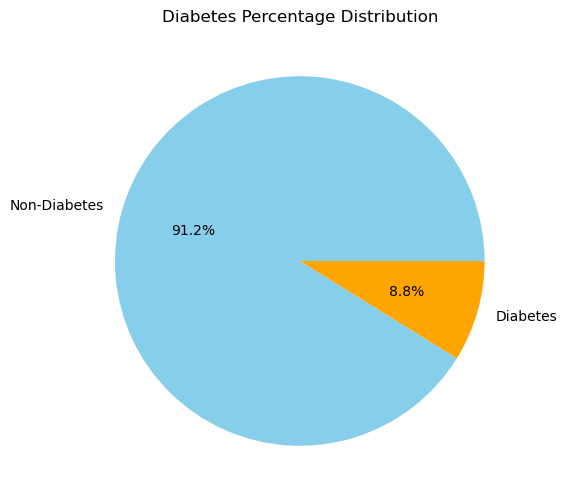

In [20]:
dist = diabetes_df['diabetes'].value_counts().sort_index()
percent = diabetes_df['diabetes'].value_counts(normalize=True).sort_index() * 100

# Percentage Pie Chart
plt.figure(figsize=(6,6))
plt.pie(percent, labels=['Non-Diabetes', 'Diabetes'],
        autopct='%1.1f%%', colors=['skyblue', 'orange'])
plt.title("Diabetes Percentage Distribution")
plt.show()

# ✅What is the gender distribution of patients? Is diabetes prevalence different between males and females? 

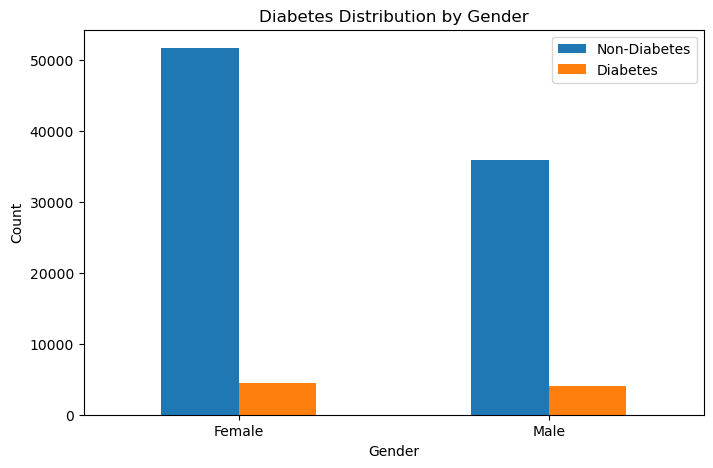

In [21]:
gender_breakdown = pd.crosstab(diabetes_df['gender'], diabetes_df['diabetes'])

gender_breakdown.plot(kind='bar', figsize=(8,5))
plt.title("Diabetes Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(['Non-Diabetes', 'Diabetes'])
plt.show()

# ✅Is age correlated with diabetes diagnosis?

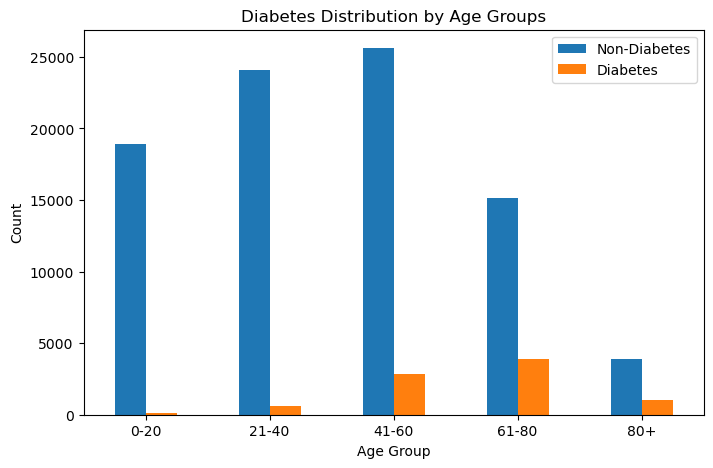

In [22]:
# Create age groups
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '21-40', '41-60', '61-80', '80+']

diabetes_df['age_group'] = pd.cut(diabetes_df['age'], bins=bins, labels=labels, right=False)
age_breakdown = pd.crosstab(diabetes_df['age_group'], diabetes_df['diabetes'])

age_breakdown.plot(kind='bar', figsize=(8,5))
plt.title("Diabetes Distribution by Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(['Non-Diabetes', 'Diabetes'])
plt.show()

# ✅Which age group has the most diabetes? create age group of <30, 30-39, 40-49

In [23]:
# divide the age into group
bins = [0, 12, 18, 44, 64, float('inf')]
labels = ["Childhood", "Adolescence", "Young Adulthood", "Middle Age", "Older Adulthood"]
diabetes_df["age_group"] = pd.cut(
    diabetes_df["age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
diabetes_df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,hba1c_level,blood_glucose_level,diabetes,age_group
0,Female,80.0,0,1,never,25.19,6.6,140,0,Older Adulthood
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,Middle Age
2,Male,28.0,0,0,never,27.32,5.7,158,0,Young Adulthood
3,Female,36.0,0,0,current,23.45,5.0,155,0,Young Adulthood
4,Male,76.0,1,1,current,20.14,4.8,155,0,Older Adulthood


In [24]:
# Let's check the age group with highest diabetes
diabetes_df2 = diabetes_df[diabetes_df["diabetes"] == 1]
diabetes_df2 = diabetes_df2[["age_group", "gender"]].groupby("age_group").value_counts().reset_index()
diabetes_df2

C:\Users\celin\AppData\Local\Temp\ipykernel_18464\1919442593.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,age_group,gender,count
0,Childhood,Female,22
1,Childhood,Male,14
2,Adolescence,Female,30
3,Adolescence,Male,26
4,Young Adulthood,Female,566
5,Young Adulthood,Male,448
6,Middle Age,Female,1824
7,Middle Age,Male,1767
8,Older Adulthood,Female,2005
9,Older Adulthood,Male,1780


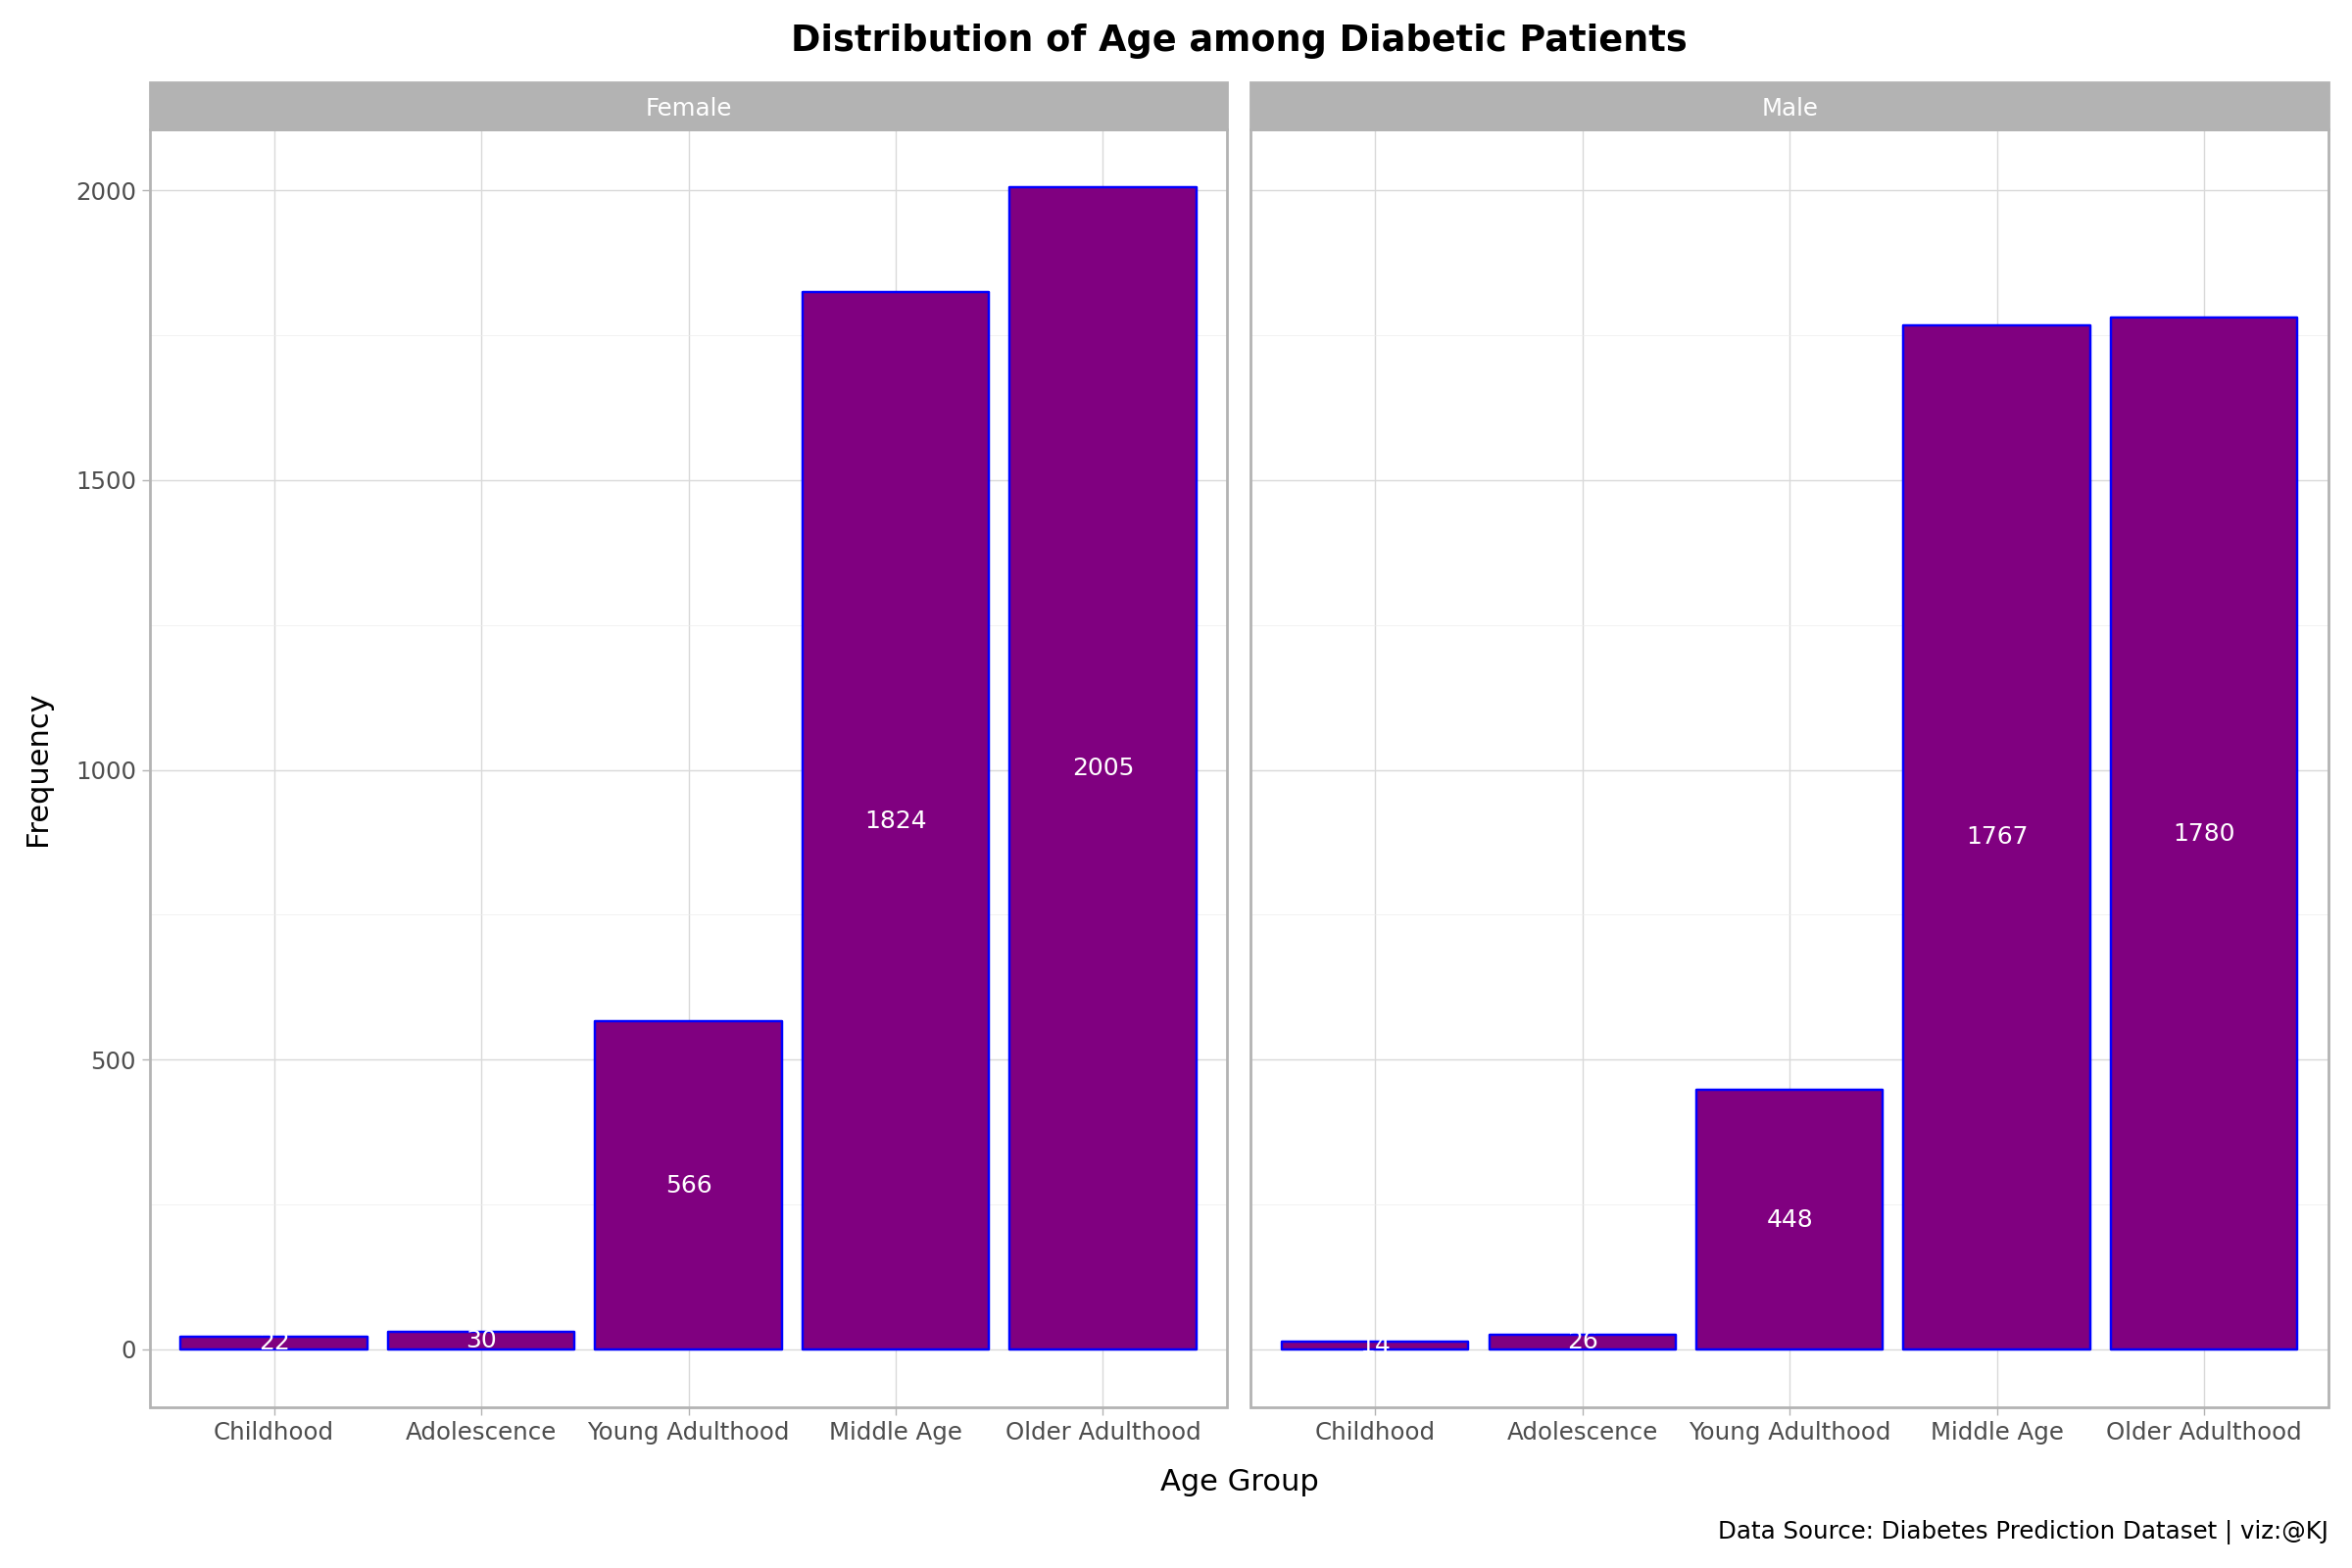

In [25]:
# Visualize the age group of the population
(ggplot(diabetes_df2, aes("age_group", "count"))
+ geom_col(fill="purple", color="blue")
+ facet_wrap("gender")
+ geom_text(aes(label="count"), position = position_stack(vjust = 0.5), size=9, color="white")
+ labs(x = "Age Group", 
       y = "Frequency", 
       title = "Distribution of Age among Diabetic Patients", 
       caption = "Data Source: Diabetes Prediction Dataset | viz:@KJ")
+ theme_light()
+ theme(figure_size=(12,8),
         plot_title = element_text(weight = "bold"))
)

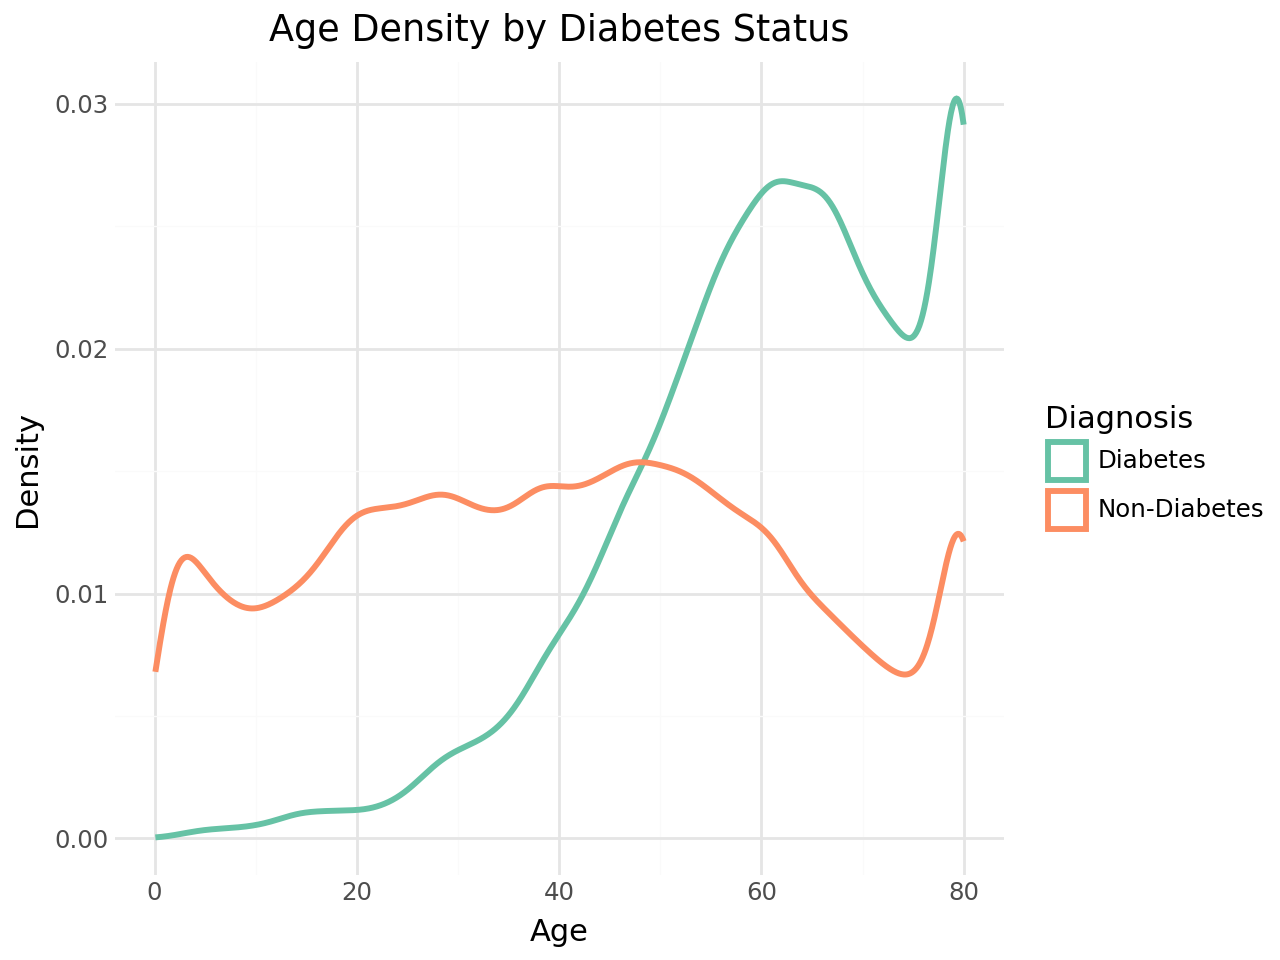

In [26]:
diabetes_df = pd.read_csv("diabetes_prediction_dataset.csv")

# Create readable labels
diabetes_df['diabetes_label'] = diabetes_df['diabetes'].map({0: 'Non-Diabetes', 1: 'Diabetes'})

# Let's visualize
(ggplot(diabetes_df, aes(x='age', color='diabetes_label')) +
    geom_density(size=1.2) +
    labs(
        title="Age Density by Diabetes Status",
        x="Age",
        y="Density",
        color="Diagnosis"
    ) +
    scale_color_manual(values=["#66c2a5", "#fc8d62"]) +
    theme_minimal())

# ✅Is hypertension associated with a diabetes diagnosis? This means Do patients with hypertension have higher diabetes rates

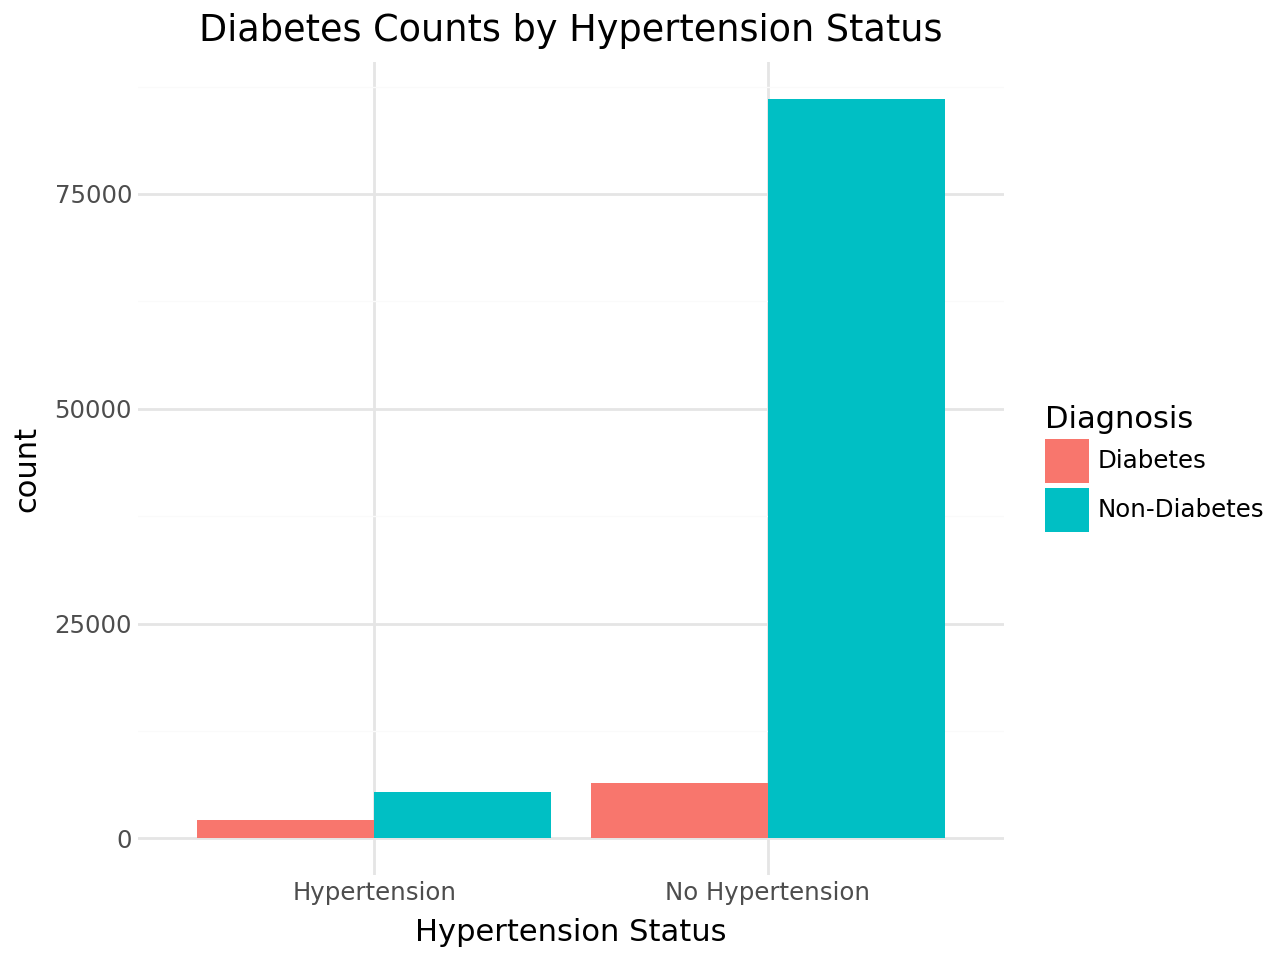

In [27]:
diabetes_df = pd.read_csv("diabetes_prediction_dataset.csv")

# Label variables
diabetes_df['diabetes_label'] = diabetes_df['diabetes'].map({0: 'Non-Diabetes', 1: 'Diabetes'})
diabetes_df['hypertension_label'] = diabetes_df['hypertension'].map({0: 'No Hypertension', 1: 'Hypertension'})

# Let's visualize
(ggplot(diabetes_df, aes(x='hypertension_label', fill='diabetes_label')) +
    geom_bar(position='dodge') +
    labs(
        title="Diabetes Counts by Hypertension Status",
        x="Hypertension Status",
        y="count",
        fill="Diagnosis"
    ) +
    theme_minimal())

# ✅Is heart disease associated with diabetes diagnosis? 

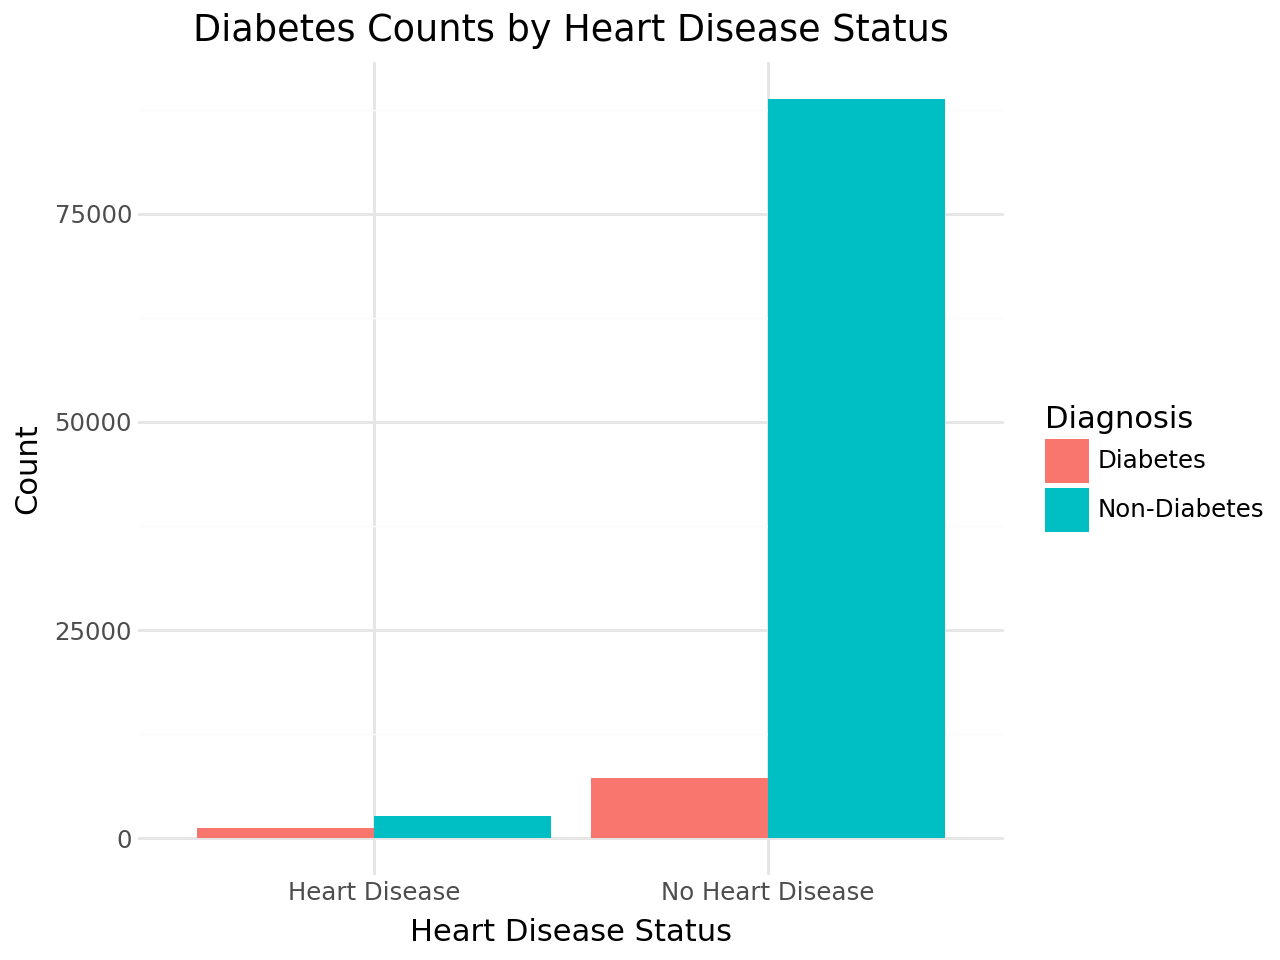

In [28]:
diabetes_df = pd.read_csv("diabetes_prediction_dataset.csv")

# Labels
diabetes_df['diabetes_label'] = diabetes_df['diabetes'].map({0: 'Non-Diabetes', 1: 'Diabetes'})
diabetes_df['heart_label'] = diabetes_df['heart_disease'].map({0: 'No Heart Disease', 1: 'Heart Disease'})

# Let's visualize
(ggplot(diabetes_df, aes(x='heart_label', fill='diabetes_label')) +
    geom_bar(position='dodge') +
    labs(
        title="Diabetes Counts by Heart Disease Status",
        x="Heart Disease Status",
        y="Count",
        fill="Diagnosis"
    ) +
    theme_minimal())

# ✅Does smoking status influence diabetes prevalence? 

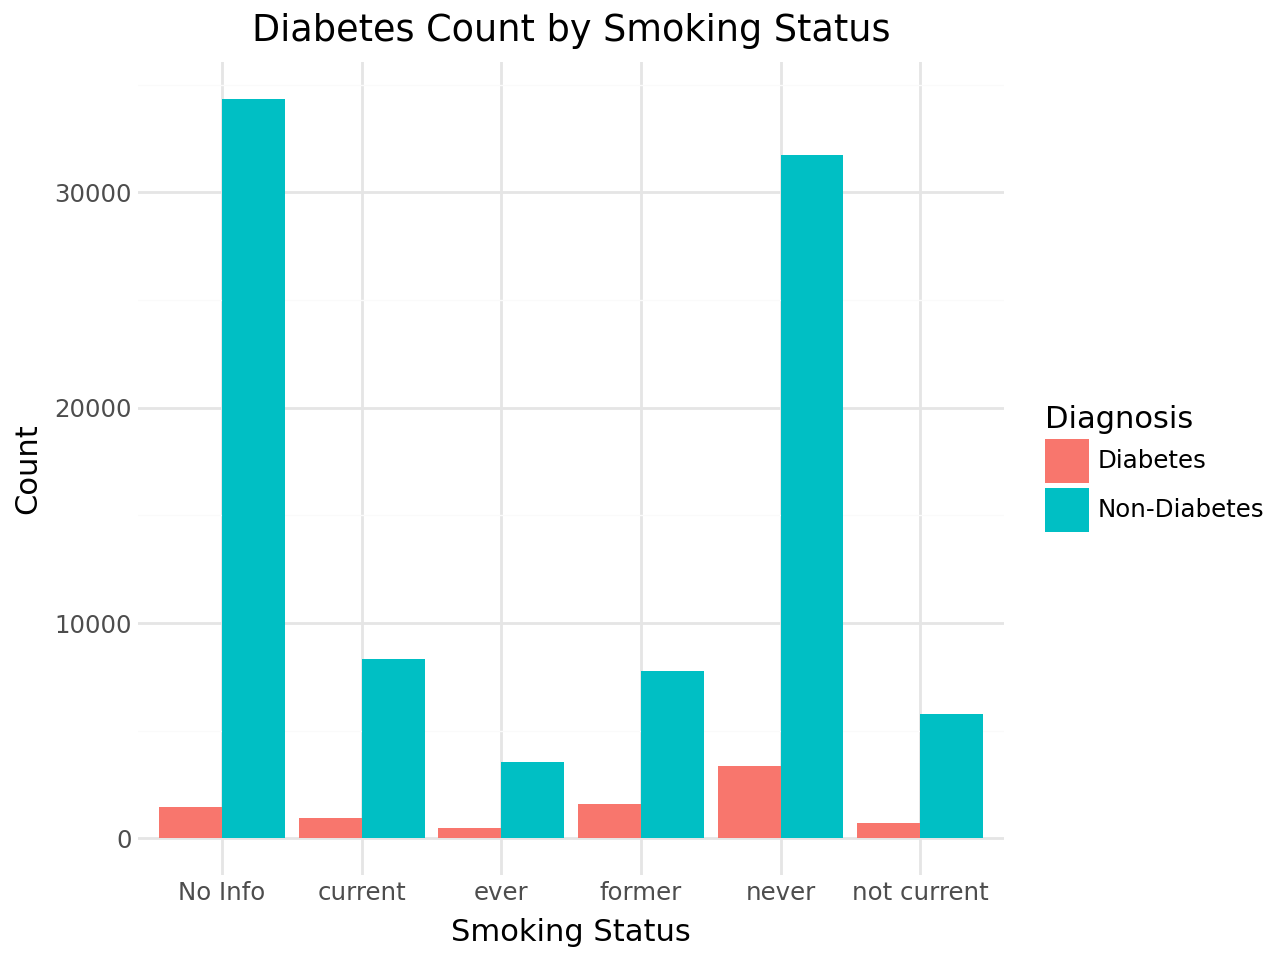

In [29]:
diabetes_df = pd.read_csv("diabetes_prediction_dataset.csv")

# Labels
diabetes_df['diabetes_label'] = diabetes_df['diabetes'].map({0: 'Non-Diabetes', 1: 'Diabetes'})

(ggplot(diabetes_df, aes(x='smoking_history', fill='diabetes_label')) +
    geom_bar(position='dodge') +
    labs(
        title="Diabetes Count by Smoking Status",
        x="Smoking Status",
        y="Count",
        fill="Diagnosis"
    ) +
    theme_minimal())

# ✅How does BMI differ between diabetic and non-diabetic patients?

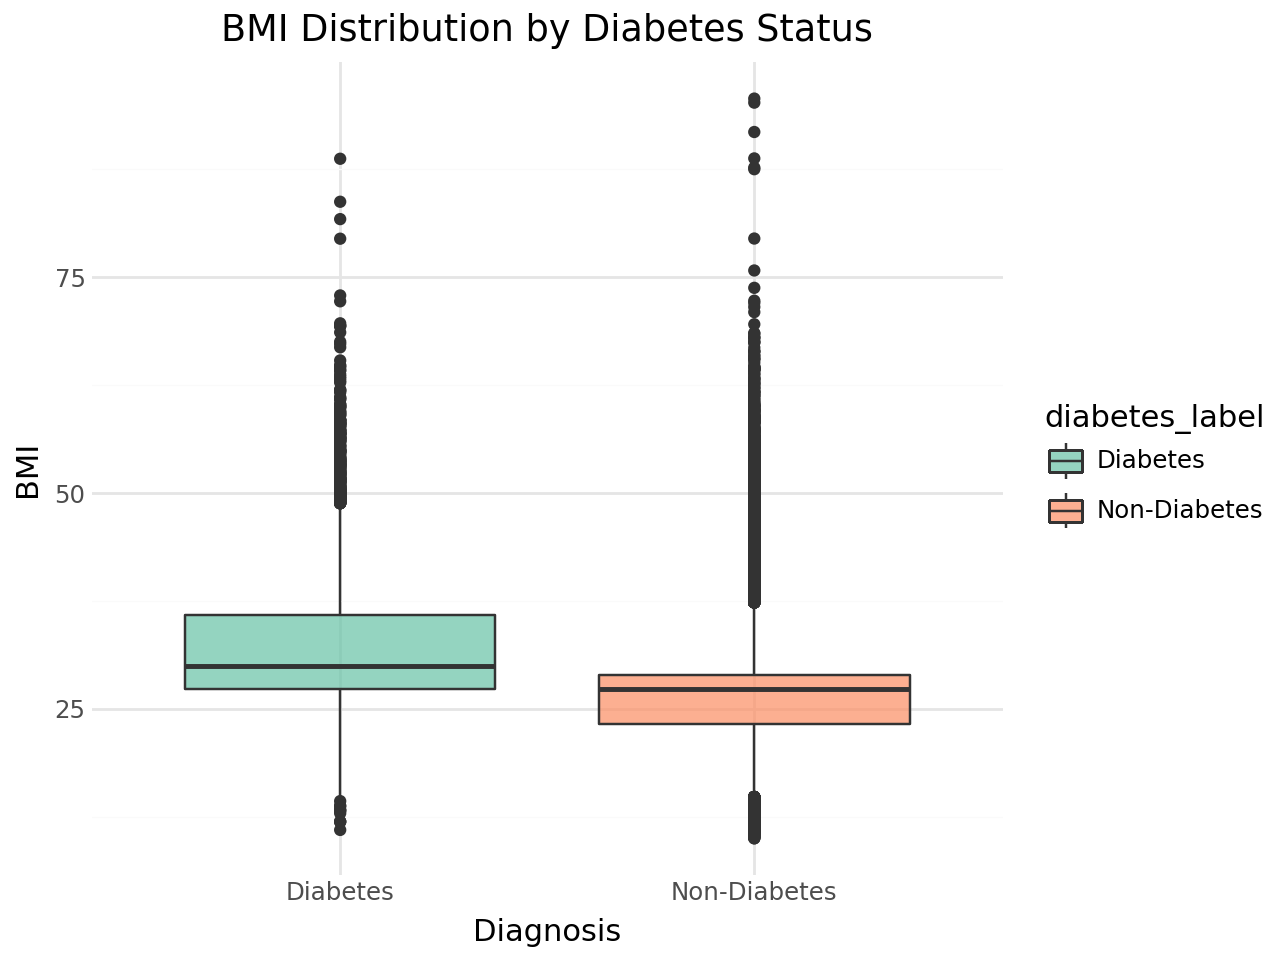

In [30]:
diabetes_df = pd.read_csv("diabetes_prediction_dataset.csv")
diabetes_df['diabetes_label'] = diabetes_df['diabetes'].map({0: 'Non-Diabetes', 1: 'Diabetes'})

(ggplot(diabetes_df, aes(x='diabetes_label', y='bmi', fill='diabetes_label')) +
    geom_boxplot(alpha=0.7) +
    labs(
        title="BMI Distribution by Diabetes Status",
        x="Diagnosis",
        y="BMI"
    ) +
    scale_fill_manual(values=["#66c2a5", "#fc8d62"]) +
    theme_minimal())

# ✅How does HbA1c level differ between diabetic and non-diabetic patients?

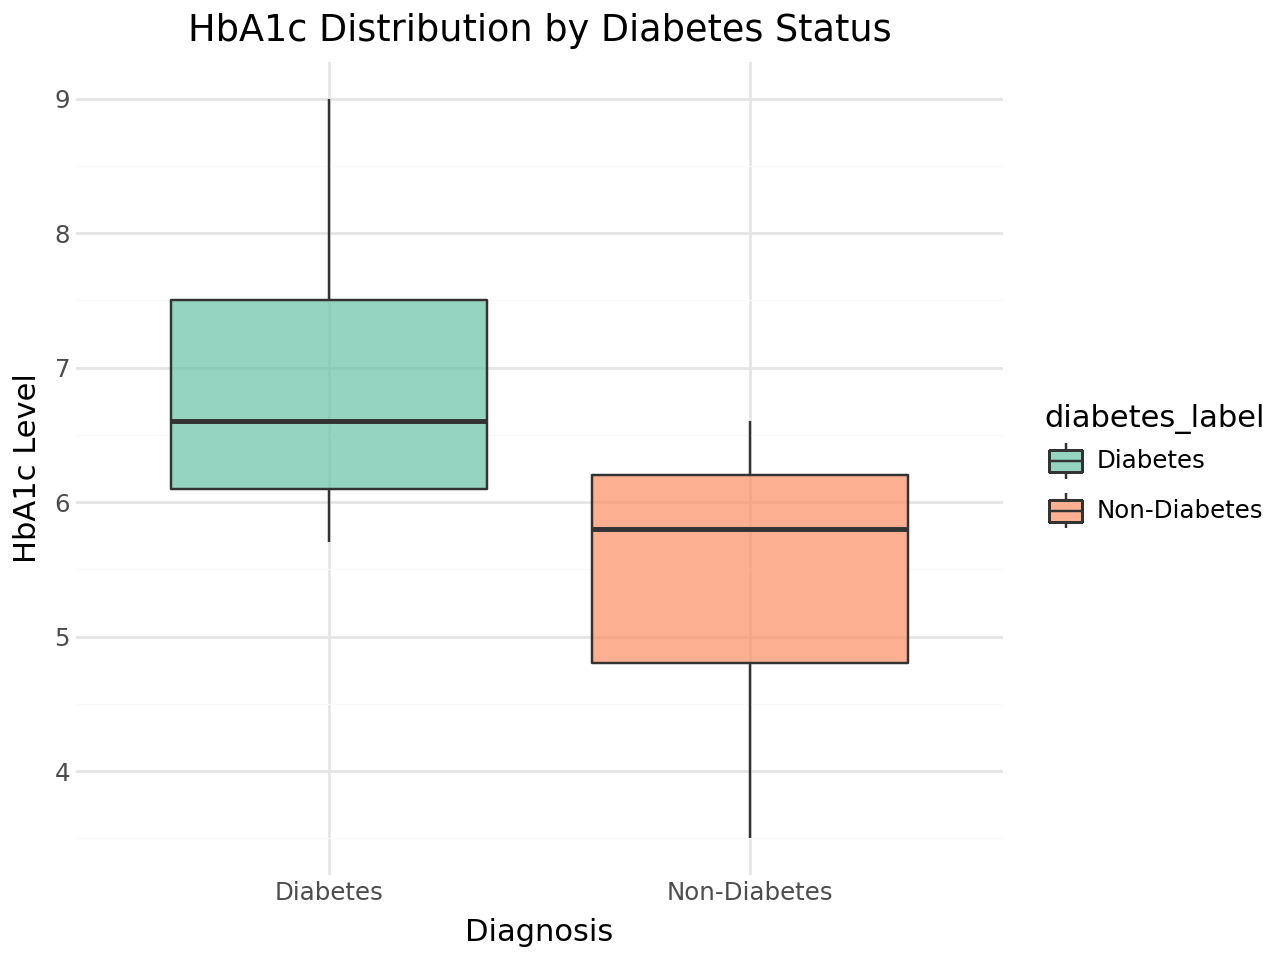

In [31]:
diabetes_df = pd.read_csv("diabetes_prediction_dataset.csv")
diabetes_df['diabetes_label'] = diabetes_df['diabetes'].map({0: 'Non-Diabetes', 1: 'Diabetes'})

(ggplot(diabetes_df, aes(x='diabetes_label', y='HbA1c_level', fill='diabetes_label')) +
    geom_boxplot(alpha=0.7) +
    labs(
        title="HbA1c Distribution by Diabetes Status",
        x="Diagnosis",
        y="HbA1c Level"
    ) +
    scale_fill_manual(values=["#66c2a5", "#fc8d62"]) +
    theme_minimal())

# ✅ Does blood glucose levels differ between diabetic and non diabetic patients?

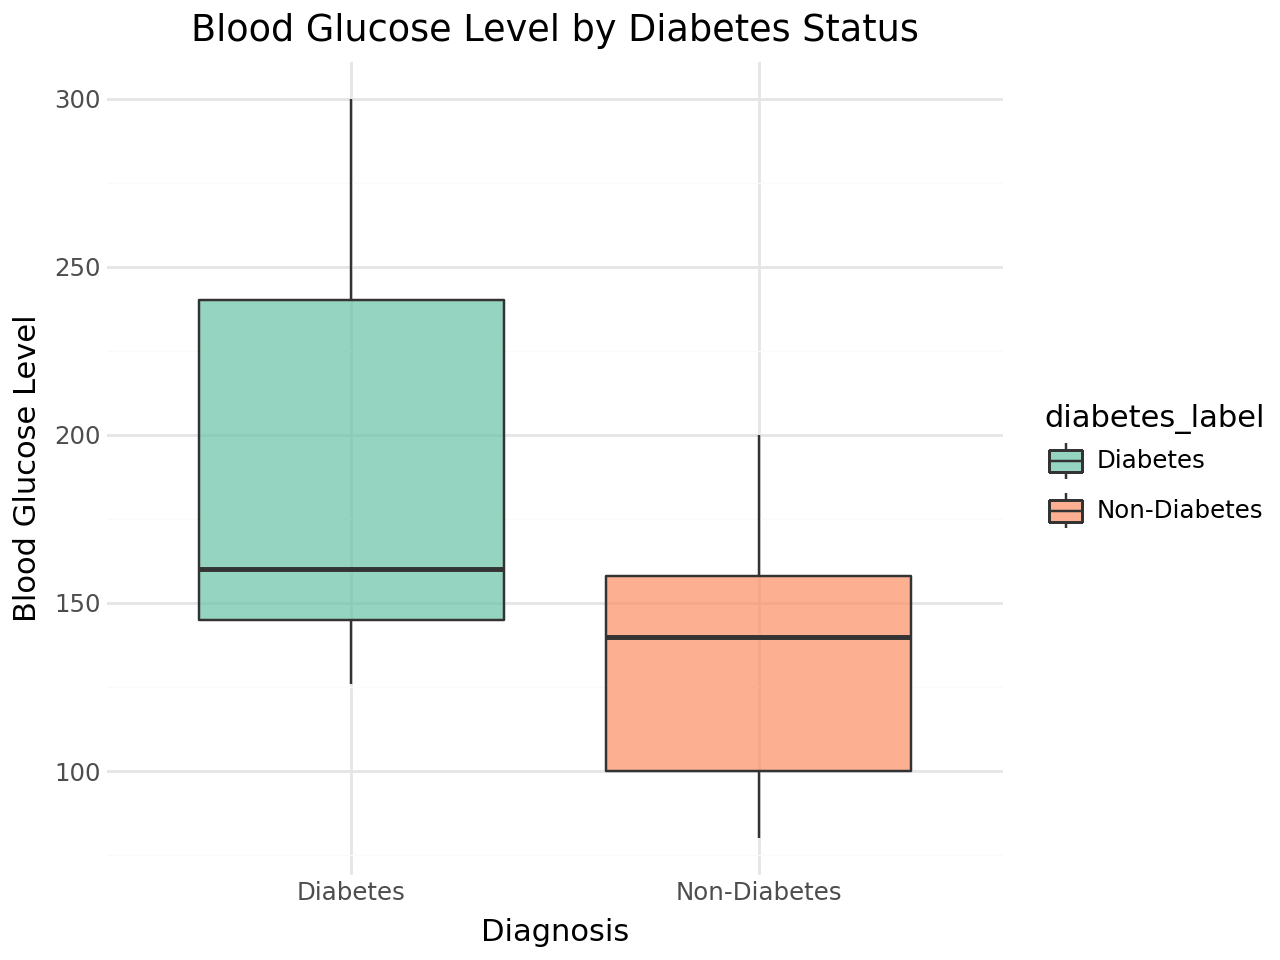

In [32]:
diabetes_df = pd.read_csv("diabetes_prediction_dataset.csv")
diabetes_df['diabetes_label'] = diabetes_df['diabetes'].map({0: 'Non-Diabetes', 1: 'Diabetes'})

(ggplot(diabetes_df, aes(x='diabetes_label', y='blood_glucose_level', fill='diabetes_label')) +
    geom_boxplot(alpha=0.7) +
    labs(
        title="Blood Glucose Level by Diabetes Status",
        x="Diagnosis",
        y="Blood Glucose Level"
    ) +
    scale_fill_manual(values=["#66c2a5", "#fc8d62"]) +
    theme_minimal())

# ✅Which factors show the strongest relationship with diabetes? Correlation matrix 

diabetes               1.000000
blood_glucose_level    0.419558
HbA1c_level            0.400660
age                    0.258008
bmi                    0.214357
hypertension           0.197823
heart_disease          0.171727
Name: diabetes, dtype: float64


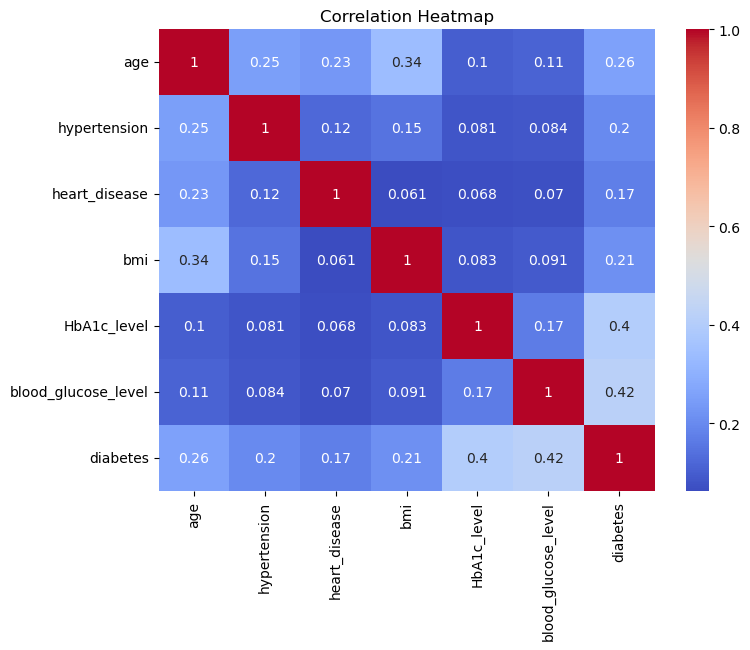

In [33]:
# Compute correlation
corr = diabetes_df.corr(numeric_only=True)

# Show correlation with diabetes
print(corr['diabetes'].sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ✅What combinations of risk factors characterize diabetic patients? Something like this(older + high BMI + high HbA1 = Diabetes)

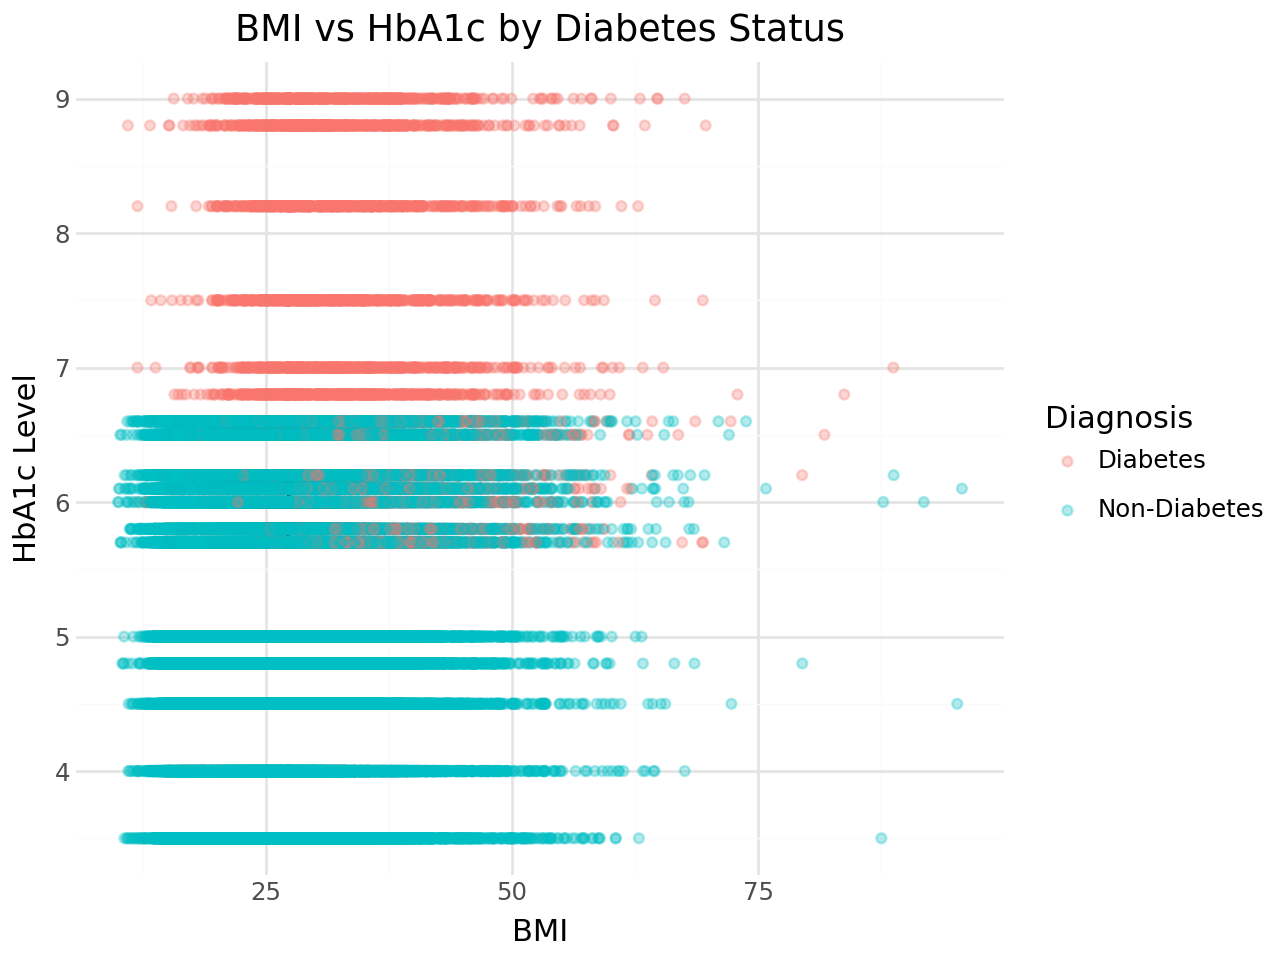

In [34]:
diabetes_df = pd.read_csv("diabetes_prediction_dataset.csv")
diabetes_df['diabetes_label'] = diabetes_df['diabetes'].map({0: 'Non-Diabetes', 1: 'Diabetes'})

(ggplot(diabetes_df, aes(x='bmi', y='HbA1c_level', color='diabetes_label')) +
    geom_point(alpha=0.3) +
    labs(
        title="BMI vs HbA1c by Diabetes Status",
        x="BMI",
        y="HbA1c Level",
        color="Diagnosis"
    ) +
    theme_minimal())

# MODELLING / LOGISTIC REGRESSION

In [35]:
diabetes_df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,diabetes_label
0,Female,80.0,0,1,never,25.19,6.6,140,0,Non-Diabetes
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,Non-Diabetes
2,Male,28.0,0,0,never,27.32,5.7,158,0,Non-Diabetes
3,Female,36.0,0,0,current,23.45,5.0,155,0,Non-Diabetes
4,Male,76.0,1,1,current,20.14,4.8,155,0,Non-Diabetes


In [36]:
diabetes_df = pd.read_csv("diabetes_prediction_dataset.csv")

# Encode categorical variables
le = LabelEncoder()
diabetes_df['gender'] = le.fit_transform(diabetes_df['gender'].astype(str))
diabetes_df['smoking_history'] = le.fit_transform(diabetes_df['smoking_history'].astype(str))

# Features and target
X = diabetes_df.drop('diabetes', axis=1)
y = diabetes_df['diabetes']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [38]:
diabetes_df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
lr = LogisticRegression()  # Initialize the logistic regression model
lr.fit(X_train_scaled, y_train)  # Train the model on scaled training data
y_train_pred = lr.predict(X_train_scaled)

In [41]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))

Accuracy: 0.8882
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18292
           1       0.43      0.88      0.57      1708

    accuracy                           0.89     20000
   macro avg       0.71      0.88      0.75     20000
weighted avg       0.94      0.89      0.90     20000

ROC AUC: 0.9616658252977588


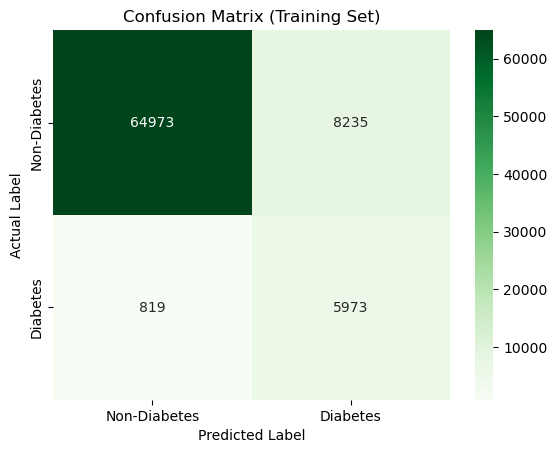

In [42]:
from sklearn.metrics import confusion_matrix
y_train_pred = lr.predict(X_train_scaled)

# Compute confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)

# Plot
sns.heatmap(
    cm_train,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Non-Diabetes', 'Diabetes'],
    yticklabels=['Non-Diabetes', 'Diabetes']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Training Set)")
plt.show()

rf

In [43]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,          # prevent deep trees
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_test_pred_rf = rf.predict(X_test)

print("Improved Random Forest:\n")
print("Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print(classification_report(y_test, y_test_pred_rf))


Improved Random Forest:

Accuracy: 0.9029
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     18292
           1       0.47      0.91      0.62      1708

    accuracy                           0.90     20000
   macro avg       0.73      0.91      0.78     20000
weighted avg       0.95      0.90      0.92     20000



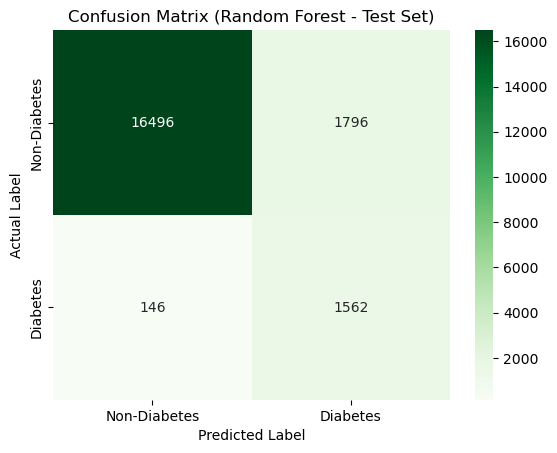

In [44]:
y_test_pred_rf = rf.predict(X_test)

# Compute confusion matrix
cm_rf_test = confusion_matrix(y_test, y_test_pred_rf)

sns.heatmap(
    cm_rf_test,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Non-Diabetes', 'Diabetes'],
    yticklabels=['Non-Diabetes', 'Diabetes']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Random Forest - Test Set)")
plt.show()

In [45]:
from sklearn.inspection import permutation_importance

rf.fit(X_train, y_train)

result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)

perm_importance = pd.Series(result.importances_mean, index=X.columns)
perm_importance.sort_values(ascending=False).head(10)


HbA1c_level            0.059015
blood_glucose_level    0.046760
hypertension           0.000730
gender                 0.000135
heart_disease         -0.000165
smoking_history       -0.000745
age                   -0.004610
bmi                   -0.004625
dtype: float64

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

# Model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

feature_importances = []

# Cross-validation
for train_idx, val_idx in cv.split(X, y):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
    
    rf.fit(X_train_cv, y_train_cv)
    feature_importances.append(rf.feature_importances_)

mean_importance = np.mean(feature_importances, axis=0)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': mean_importance
})
# Sort features
importance_df = importance_df.sort_values(by='Importance', ascending=False)


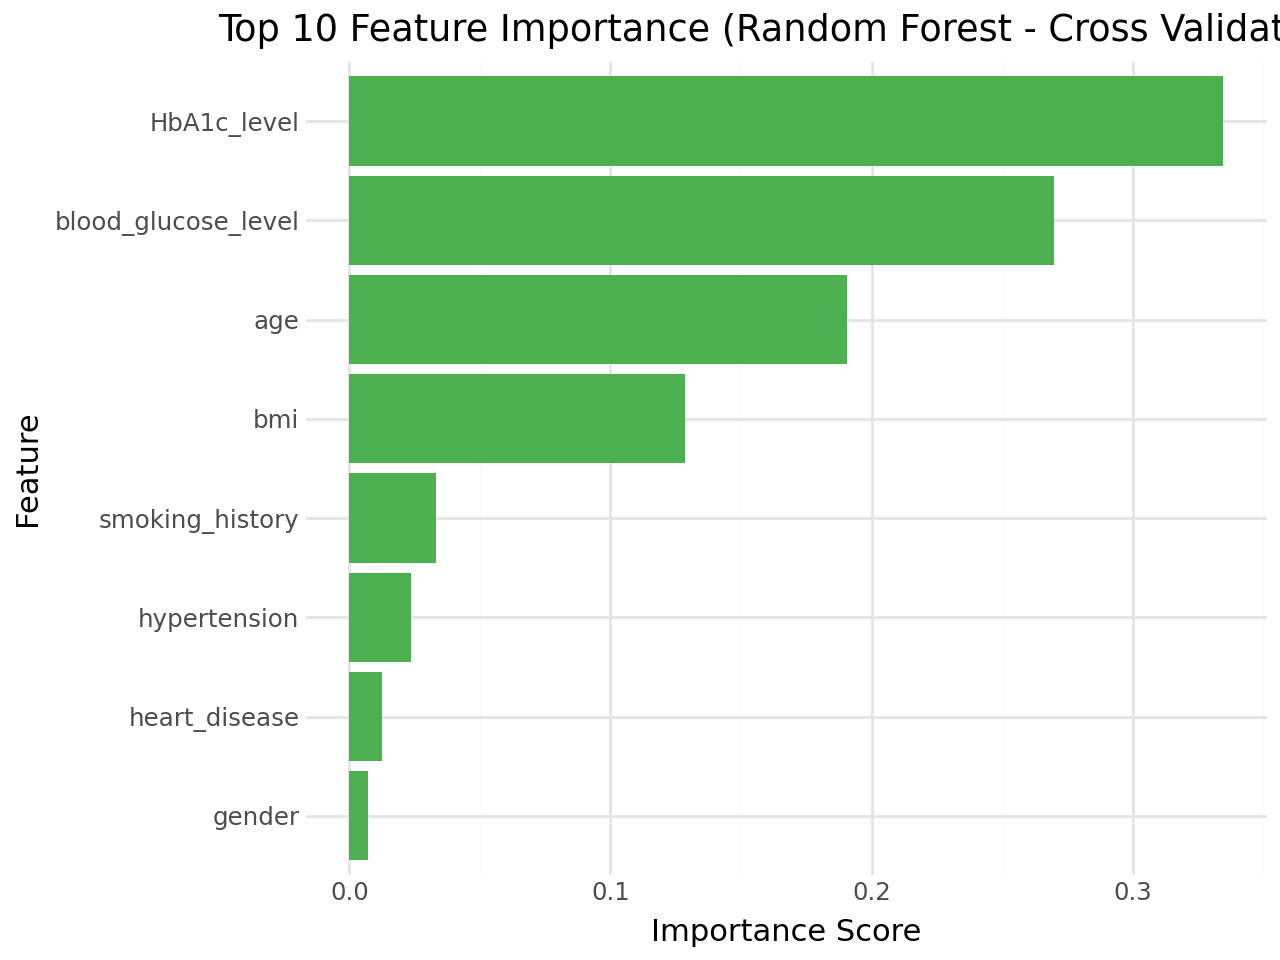

In [47]:
(ggplot(importance_df.head(10), aes(x='reorder(Feature, Importance)', y='Importance')) +
    geom_bar(stat='identity', fill='#4CAF50') +
    coord_flip() +  # horizontal bars
    labs(
        title="Top 10 Feature Importance (Random Forest - Cross Validation)",
        x="Feature",
        y="Importance Score"
    ) +
    theme_minimal()
)

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Step 1: Logistic Regression Evaluation
y_pred_log = lr.predict(X_test_scaled)
y_prob_log = lr.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))

# Step 2: Random Forest Evaluation
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("\nRandom Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

Logistic Regression Performance:
Accuracy: 0.8882
Precision: 0.4252124645892351
Recall: 0.8788056206088993
F1 Score: 0.5731195112638412
ROC AUC: 0.9616658252977588

Random Forest Performance:
Accuracy: 0.9932
Precision: 0.9781021897810219
Recall: 0.9414519906323185
F1 Score: 0.9594272076372315
ROC AUC: 0.9951657722934381


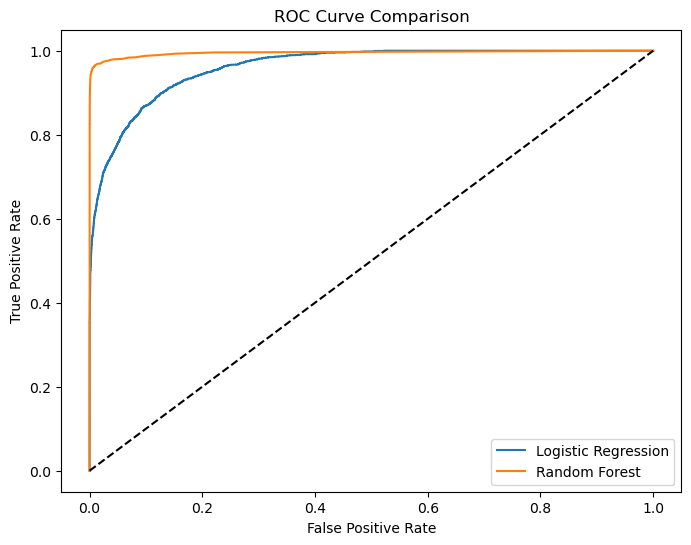

In [49]:
plt.figure(figsize=(8,6))

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'k--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

✅DIABETES DATAESET SUMMARY

* This project analyzes a diabetes prediction dataset using Exploratory Data Analysis (EDA) and machine learning techniques. The goal is to identify key risk factors associated with diabetes and build a predictive model for early detection. The dataset is highly imbalanced, with 91.5% of individuals classified as non-diabetic and only 8.5% classified as diabetic. This imbalance is an important consideration during model development, as it may affect the model’s ability to accurately identify diabetic cases. Appropriate evaluation metrics and imbalance-handling techniques may be required to ensure reliable predictions.


Dataset Characteristics
Total samples: 100,000

Target variable: diabetes (0 = Non-diabetic, 1 = Diabetic)

Class distribution:

Non-diabetic: 91.5%

Diabetic: 8.5%